In [32]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [33]:
# Importing the dataset
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values

# Polynomial regression
works on non linear data, where we transform (sqauare the values) data to represent data points in any non linear format like cone/parabola, etc.. that fits the data.


In [34]:
dataset
# input is level and output is salary

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [35]:
X[0]

array([1])

In [36]:
y[0]

np.int64(45000)

In [37]:
# Fitting Linear Regression to the dataset
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

LinearRegression()

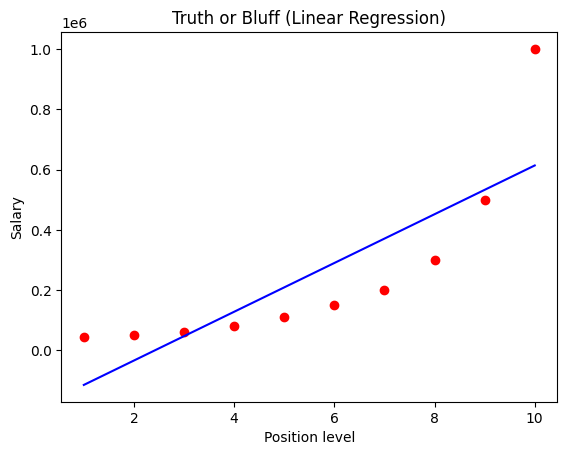

In [38]:
# Visualising the Linear Regression results
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg.predict(X), color = 'blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

In [39]:
# Fitting Polynomial Regression to the dataset
#above graph doesn't represent all data points, having more errors.
#need to apply polynomial features (transfromational methodology) as part of preprocessing
# 5th degree means - x,x square, x cube, x to power of 4, x to power of 5 - for each x column value
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 5)
X_poly = poly_reg.fit_transform(X)
#poly_reg.fit(X_poly, y)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)

LinearRegression()

In [40]:
X_poly

array([[1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00],
       [1.0000e+00, 2.0000e+00, 4.0000e+00, 8.0000e+00, 1.6000e+01,
        3.2000e+01],
       [1.0000e+00, 3.0000e+00, 9.0000e+00, 2.7000e+01, 8.1000e+01,
        2.4300e+02],
       [1.0000e+00, 4.0000e+00, 1.6000e+01, 6.4000e+01, 2.5600e+02,
        1.0240e+03],
       [1.0000e+00, 5.0000e+00, 2.5000e+01, 1.2500e+02, 6.2500e+02,
        3.1250e+03],
       [1.0000e+00, 6.0000e+00, 3.6000e+01, 2.1600e+02, 1.2960e+03,
        7.7760e+03],
       [1.0000e+00, 7.0000e+00, 4.9000e+01, 3.4300e+02, 2.4010e+03,
        1.6807e+04],
       [1.0000e+00, 8.0000e+00, 6.4000e+01, 5.1200e+02, 4.0960e+03,
        3.2768e+04],
       [1.0000e+00, 9.0000e+00, 8.1000e+01, 7.2900e+02, 6.5610e+03,
        5.9049e+04],
       [1.0000e+00, 1.0000e+01, 1.0000e+02, 1.0000e+03, 1.0000e+04,
        1.0000e+05]])

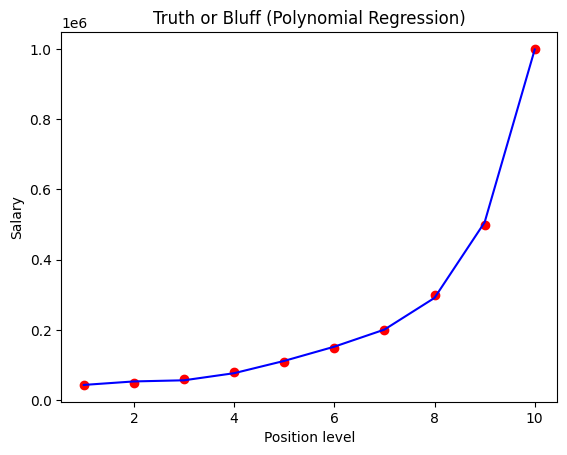

In [41]:
# Visualising the Polynomial Regression results
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg_2.predict(poly_reg.fit_transform(X)), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

In [42]:
y_pred = lin_reg_2.predict(poly_reg.fit_transform(np.array([7]).reshape(-1, 1)))

In [43]:
#Regression Evaluation Metrics
# rmse value is buffer i.e. predicted value would be + or - that data point value
from sklearn import metrics
print('RMSE:', np.sqrt(metrics.mean_squared_error(np.array([200000]), y_pred)))

RMSE: 1349.650349624455


In [44]:
y_pred

array([201349.65034962])

#Random forest regressor

In [45]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [46]:
# Importing the dataset
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values

In [47]:
# Fitting Random Forest Regression to the dataset
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 50, random_state = 0, max_depth=5)
regressor.fit(X, y)

RandomForestRegressor(max_depth=5, n_estimators=50, random_state=0)

In [48]:
# Predicting a new result
y_pred = regressor.predict(np.array([7]).reshape(1, -1))
print(y_pred)

[191600.]


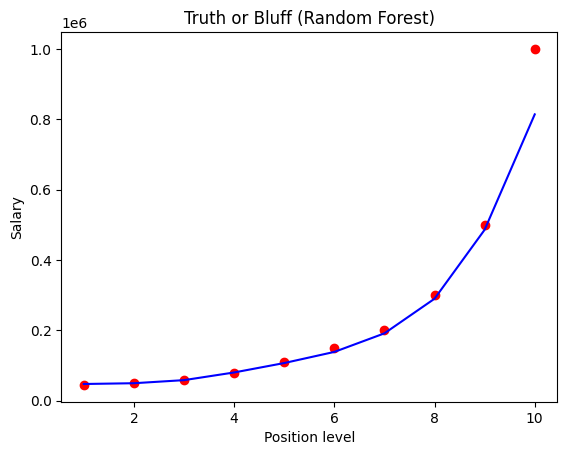

In [49]:
# Visualising the Random Forest results
plt.scatter(X, y, color = 'red')
plt.plot(X, regressor.predict(X), color = 'blue')
plt.title('Truth or Bluff (Random Forest)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

In [50]:
#Regression Evaluation Metrics
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y, regressor.predict(X)))
print('MSE:', metrics.mean_squared_error(y, regressor.predict(X)))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y, regressor.predict(X))))

MAE: 23700.0
MSE: 3510492222.2222223
RMSE: 59249.40693561601


#Support vector regressor

In [51]:
# Importing the dataset
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values

In [52]:
X

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [53]:
# Fitting SVR to the dataset
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf', C=1)
regressor.fit(X, y)

SVR(C=1)

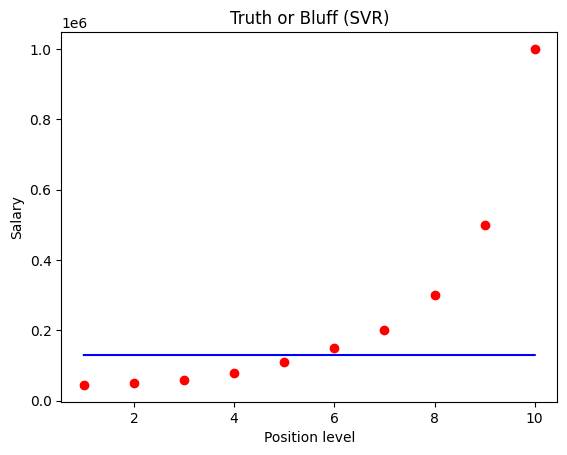

In [54]:
# Visualising the SVR results
plt.scatter(X, y, color = 'red')
plt.plot(X, regressor.predict(X), color = 'blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

In [55]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X)
y = y.reshape(-1, 1)
y = sc_y.fit_transform(y)

In [56]:
y[1]

array([-0.70243757])

In [57]:
# Fitting SVR to the dataset
from sklearn.svm import SVR
regressor1 = SVR(kernel = 'rbf', C=50)
regressor1.fit(X, np.ravel(y))

SVR(C=50)

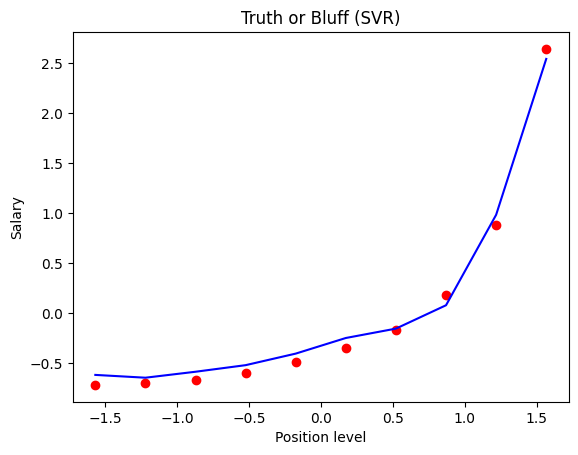

In [58]:
# Visualising the SVR results
plt.scatter(X, y, color = 'red')
plt.plot(X, regressor1.predict(X), color = 'blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

In [59]:
# Predicting a new result, its in scaled form
y_pred = regressor1.predict(np.array([7]).reshape(1, -1))
#y_pred = sc_y.inverse_transform(y_pred)
print(y_pred)

[0.77417982]


In [60]:


y_pred = y_pred.reshape(-1, 1)
y_pred = sc_y.inverse_transform(y_pred)


In [61]:
y[2]

array([-0.66722767])

In [62]:
#Regression Evaluation Metrics
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y, regressor1.predict(X)))
print('MSE:', metrics.mean_squared_error(y, regressor1.predict(X)))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y, regressor1.predict(X))))

MAE: 0.08116514310095879
MSE: 0.0072475628493566275
RMSE: 0.08513261918534298
